# imgsym playground

Interactive tour of the library: axis **detection**, axis **scoring**, the PatchNN **local-symmetry heatmap**.

In [6]:
import math
import cv2
import matplotlib.pyplot as plt
import imgsym


def show(bgr, title=None, figsize=(7, 7), save=None):
    if save:
        cv2.imwrite(f"assets/{save}", bgr)
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

print("detectors       :", imgsym.list_detectors())
print("mask detectors  :", imgsym.list_mask_detectors())
print("scoring methods :", imgsym.list_methods())

detectors       : ['nxc', 'wavelets', 'xfeatures']
mask detectors  : ['r_lip']
scoring methods : ['pixel_correlation', 'sliding_window', 'dct', 'eros', 'gradient', 'multi_scale_gradient', 'hog', 'phog', 'gabor', 'alexnet', 'deep_features', 'weighted_binary', 'local_global']


## 1. Detect symmetry axes

### Natural images

axis 1: angle   90.0 deg  center (640, 448)  length 826  strength 1.00
axis 2: angle   93.0 deg  center (634, 467)  length 795  strength 0.74
axis 3: angle   87.0 deg  center (640, 525)  length 705  strength 0.34
axis 4: angle   96.0 deg  center (627, 467)  length 875  strength 0.31
axis 5: angle    0.0 deg  center (640, 371)  length 813  strength 0.19
axis 6: angle   84.0 deg  center (640, 499)  length 881  strength 0.16


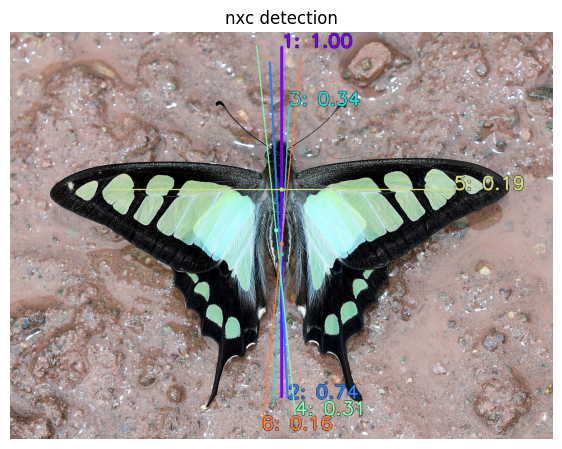

axis 1: angle   91.0 deg  center (637, 482)  length 936  strength 1.00
axis 2: angle   18.0 deg  center (560, 499)  length 1120  strength 0.88
axis 3: angle   37.0 deg  center (676, 425)  length 1144  strength 0.88
axis 4: angle   90.0 deg  center (634, 482)  length 936  strength 0.87
axis 5: angle    0.0 deg  center (633, 483)  length 1243  strength 0.85


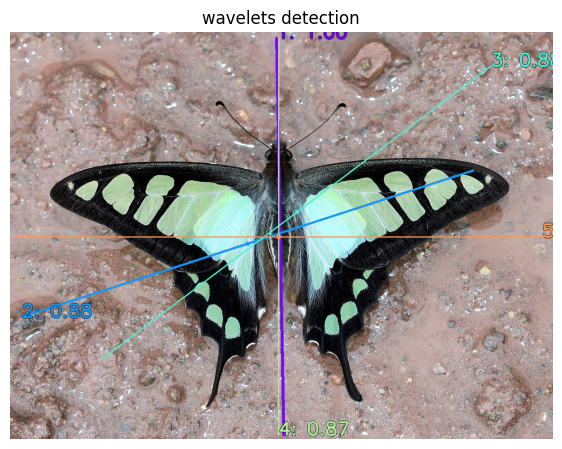

axis 1: angle   92.0 deg  center (634, 439)  length 741  strength 1.00


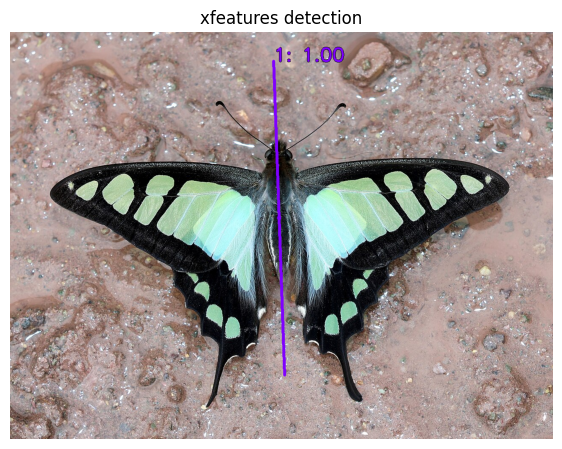

In [7]:
DETECTORS = ['nxc', 'wavelets', 'xfeatures']

img = cv2.imread("assets/butterfly.jpg")

for method in DETECTORS:
    axes = imgsym.detect_axes(img, detector=method)

    angles, midpoints, seg_lengths, strengths = axes
    for i, (a, m, L, s) in enumerate(zip(angles, midpoints, seg_lengths, strengths)):
        print(f"axis {i + 1}: angle {math.degrees(a):6.1f} deg  "
            f"center ({m[0]:.0f}, {m[1]:.0f})  length {L:.0f}  strength {s:.2f}")

    show(imgsym.visualize(img, axes), f"{method} detection", save=f"butterfly_axes_{method}.png")

### Binary shapes

axes at: [18.0, 54.0, 90.0, 126.0, 162.0]


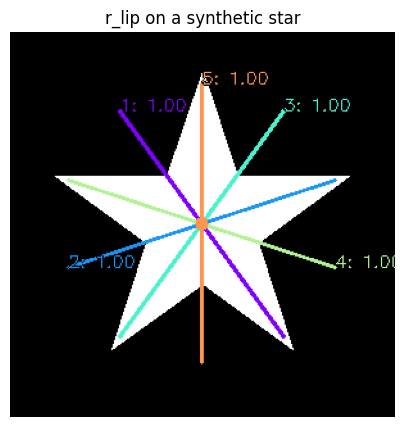

In [8]:
mask = cv2.imread("assets/synthetic_star.png", cv2.IMREAD_GRAYSCALE)

# A five-pointed star has five mirror axes; the measures separate them from
# rotation-only angles (~1.0 vs ~0.5) - that is what `threshold` filters.
star_axes = imgsym.detect_axes_from_mask(mask, detector="r_lip", mode="multi", threshold=0.9)
print("axes at:", sorted(round(math.degrees(t), 1) for t in star_axes[0]))
show(imgsym.visualize(cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR), star_axes),
     "r_lip on a synthetic star", figsize=(5, 5), save="synthetic_star_axes_lip.png")

## 2. Score symmetry along an axis

Scores are comparable **within** a method (scales differ across methods).
Below: the detected axis vs the same axis rotated by `WRONG_DEG`.

In [9]:
WRONG_DEG = 5 # try 10, 15, 30 ...
METHODS = ['pixel_correlation', 'sliding_window', 'dct', 'eros', 'gradient', 'multi_scale_gradient', 'hog', 'phog', 'gabor', 'alexnet', 'deep_features', 'weighted_binary', 'local_global']

true_axis = imgsym.get_axis(axes)              # strongest detected axis
# same axis rotated by WRONG_DEG about its midpoint
rot = (axes[0].copy(), axes[1], axes[2], axes[3])
rot[0][0] += math.radians(WRONG_DEG)
wrong_axis = imgsym.get_axis(rot)
rot[0][0] -= math.radians(WRONG_DEG)

print(f"{'method':20s} {'true axis':>10s} {WRONG_DEG:>6d} deg off")
for m in METHODS:
    s_true = imgsym.score_along_axis(img, true_axis, method=m)
    s_wrong = imgsym.score_along_axis(img, wrong_axis, method=m)
    print(f"{m:20s} {s_true:10.3f} {s_wrong:10.3f}")

method                true axis      5 deg off
pixel_correlation         0.960      0.907
sliding_window            0.001      0.000
dct                       0.914      0.774
eros                   2066.072   1556.964
gradient                  7.954      6.081
multi_scale_gradient      0.873      0.862
hog                       0.885      0.843
phog                      0.994      0.983
gabor                     0.711      0.500
alexnet                   0.657      0.524
deep_features             0.494      0.432
weighted_binary          14.444     10.921
local_global              0.158      0.148


## 3. PatchNN local-symmetry heatmap

`local_global` (PatchNN, Hogeweg et al. 2017) can visualize its score:
`calculate_heatmap` returns per-patch mirror-match quality about the vertical
center column of the given image. So we axis-align first: rotate the detected
axis to vertical and shift it onto the exact center column (odd width). The
optional refinement sharpens the axis by maximizing the PatchNN score itself.
The exact NN search is O(n^2) in patches - keep inputs <= ~600 px.

score = 0.130


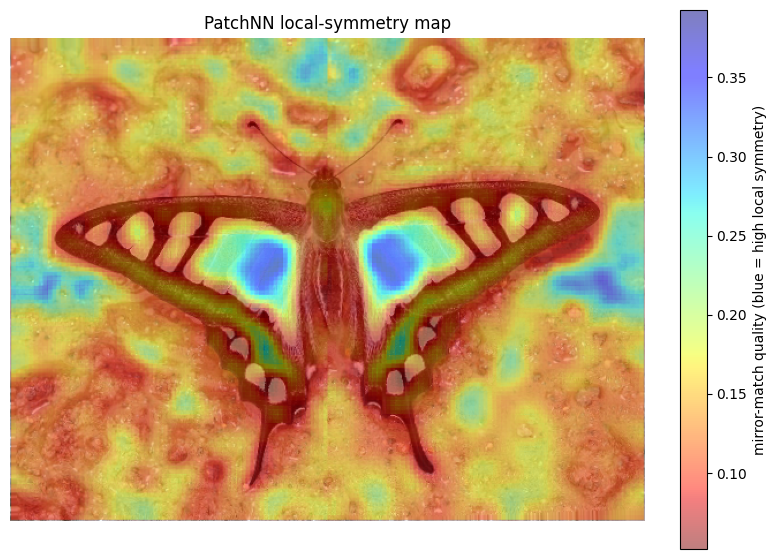

In [10]:
WORK_WIDTH = 560

bf0 = cv2.imread("assets/butterfly.jpg")
sc = WORK_WIDTH / bf0.shape[1]
bf = cv2.resize(bf0, (WORK_WIDTH, int(bf0.shape[0] * sc)))
H, W = bf.shape[:2]

ang, mid, _, _ = imgsym.detect_axes(bf, detector="xfeatures")
deg0, ax0, cy0 = math.degrees(ang[0]), float(mid[0][0]), float(mid[0][1])
calc = imgsym.SymmetryCalculatorFactory.create("local_global")

def aligned(deg, ax):
    half = int(min(ax, W - 1 - ax)) - 2
    R = cv2.getRotationMatrix2D((ax, cy0), deg - 90.0, 1.0)
    R[0, 2] += half - ax
    return cv2.warpAffine(bf, R, (2 * half + 1, H), flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_REPLICATE)


crop = aligned(deg0, ax0)
score, heat = calc.calculate_heatmap(crop)
print(f"score = {score:.3f}")

plt.figure(figsize=(9, 7))
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
hm = plt.imshow(heat, cmap="jet_r", alpha=0.5)   # blue = high local symmetry
cbar = plt.colorbar(hm, fraction=0.04)
cbar.set_label("mirror-match quality (blue = high local symmetry)")
plt.axis("off")
plt.title("PatchNN local-symmetry map")
plt.savefig("assets/butterfly_local_global_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()